## Rapport d'Analyse de Sentiment avec BERT

Ce notebook présente une implémentation complète de l'analyse de sentiment en français à l'aide du modèle pré-entraîné CamemBERT (une version de BERT adaptée au français).

### 1. Chargement des Données

Les données sont chargées à partir d'un fichier `data.csv`. Le dataset initial contient 10147 commentaires.

### 2. Nettoyage des Données

*   Suppression des lignes avec des valeurs manquantes dans les colonnes `sentiment` ou `review`.
*   Application d'une fonction `clean_text` pour :
    *   Convertir le texte en minuscules.
    *   Supprimer les URLs.
    *   Supprimer les mentions (@).
    *   Supprimer les caractères non alphabétiques.
    *   Supprimer les espaces multiples et les espaces en début/fin de chaîne.

Après nettoyage, 10145 commentaires restent.

### 3. Préparation des Labels

Les sentiments ('positive', 'neutral', 'negative') sont convertis en identifiants numériques (0, 1, 2 respectivement). La distribution des labels est la suivante :
*   **Positive (0):** 3750
*   **Negative (2):** 3311
*   **Neutral (1):** 3084

### 4. Division Train/Test

Les données sont divisées en ensembles d'entraînement et de test avec un ratio de 80/20, en utilisant une stratification pour maintenir la distribution des sentiments :
*   **Entraînement :** 8116 commentaires
*   **Test :** 2029 commentaires

### 5. Chargement de BERT et Tokenization

Le modèle `camembert-base` de Hugging Face est utilisé. Un `AutoTokenizer` et un `AutoModelForSequenceClassification` sont chargés, configurés pour 3 labels. Les textes sont ensuite tokenisés avec une longueur maximale de 256 et des padding/truncation.

### 6. Création du Dataset PyTorch

Une classe `SentimentDataset` est définie pour créer des objets `Dataset` compatibles avec PyTorch à partir des encodages et des labels tokenisés.

### 7. Configuration de l'Entraînement

Les `TrainingArguments` sont configurés pour :
*   `num_train_epochs=3`
*   `per_device_train_batch_size=16`
*   `per_device_eval_batch_size=16`
*   `eval_strategy="epoch"` et `save_strategy="epoch"`
*   `load_best_model_at_end=True` avec `metric_for_best_model="accuracy"`

Une fonction `compute_metrics` est définie pour calculer la précision.

### 8. Entraînement du Modèle

Le modèle est entraîné en utilisant la classe `Trainer` de Hugging Face.

### 9. Évaluation du Modèle

Après l'entraînement, le modèle est évalué sur l'ensemble de test. Les métriques obtenues sont :

*   **Précision globale :** 0.9571 (environ 95.71%)

#### Rapport de Classification :
```
              precision    recall  f1-score   support

     positif       0.96      0.97      0.96       750
      neutre       0.95      0.94      0.95       617
     négatif       0.96      0.96      0.96       662

    accuracy                           0.96      2029
   macro avg       0.96      0.96      0.96      2029
weighted avg       0.96      0.96      0.96      2029
```

Une matrice de confusion est également générée pour visualiser les performances par classe.

### 10. Sauvegarde du Modèle

Le modèle entraîné et le tokenizer sont sauvegardés localement dans le répertoire `./sentiment_model`.

### 11. Fonction de Prédiction

Une fonction `predict_sentiment` est implémentée pour prédire le sentiment d'un nouveau texte. Une version **robuste (`predict_sentiment_robust`)** a été ajoutée pour gérer les phrases très courtes en post-traitant les prédictions basées sur la présence de mots fortement positifs ou négatifs.

**Exemples de Prédiction :**

*   "Ce produit est génial, je l'adore !" -> **POSITIVE**
*   "Service client déplorable, très déçu." -> **NEGATIVE**
*   "Produit correct, sans plus." -> **NEUTRAL**
*   "excellent produit" -> **POSITIVE**
*   "nul" -> **NEUTRAL** (le post-traitement n'a pas impacté cet exemple)

Ce notebook démontre une approche efficace pour l'analyse de sentiment en français, avec de très bonnes performances et des capacités de prédiction robustes.

In [ ]:
# ============================================
# CLASSIFICATION DE SENTIMENTS AVEC BERT
# ============================================

import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. CHARGER LES DONNÉES
print("=" * 50)
print("📂 CHARGEMENT DES DONNÉES")
print("=" * 50)

df = pd.read_csv('data.csv')
print(f"✅ Dataset chargé : {len(df)} commentaires")

# 2. NETTOYAGE
print("\n" + "=" * 50)
print("🧹 NETTOYAGE DES DONNÉES")
print("=" * 50)

# Supprimer les lignes avec valeurs manquantes
df = df.dropna(subset=['sentiment', 'review'])
print(f"✅ Après suppression des NaN : {len(df)} commentaires")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_review'] = df['review'].apply(clean_text)
print("✅ Nettoyage terminé")

# 3. PRÉPARATION DES LABELS
print("\n" + "=" * 50)
print("🤖 PRÉPARATION POUR BERT")
print("=" * 50)

# Nettoyer les sentiments
df['sentiment'] = df['sentiment'].str.strip().str.lower()

sentiment_to_id = {
    'positive': 0,
    'neutral': 1,
    'negative': 2
}
id_to_sentiment = {v: k for k, v in sentiment_to_id.items()}

df['label'] = df['sentiment'].map(sentiment_to_id)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

print(f"Distribution :\n{df['label'].value_counts()}")

# 4. DIVISION TRAIN/TEST
print("\n" + "=" * 50)
print("✂️ DIVISION DES DONNÉES")
print("=" * 50)

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_review'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"📊 Entraînement : {len(X_train)} commentaires")
print(f"📊 Test : {len(X_test)} commentaires")

# 5. CHARGER BERT
print("\n" + "=" * 50)
print("📥 CHARGEMENT DE BERT")
print("=" * 50)

model_name = "camembert-base"  # BERT français
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    ignore_mismatched_sizes=True
)
print(f"✅ Modèle chargé")

# 6. TOKENIZATION
print("\n" + "=" * 50)
print("🔤 TOKENIZATION")
print("=" * 50)

def tokenize_function(texts):
    return tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=256,
        return_tensors="pt"
    )

train_encodings = tokenize_function(X_train)
test_encodings = tokenize_function(X_test)





📂 CHARGEMENT DES DONNÉES
✅ Dataset chargé : 10147 commentaires

🧹 NETTOYAGE DES DONNÉES
✅ Après suppression des NaN : 10145 commentaires
✅ Nettoyage terminé

🤖 PRÉPARATION POUR BERT
Distribution :
label
0    3750
2    3311
1    3084
Name: count, dtype: int64

✂️ DIVISION DES DONNÉES
📊 Entraînement : 8116 commentaires
📊 Test : 2029 commentaires

📥 CHARGEMENT DE BERT


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Modèle chargé

🔤 TOKENIZATION


In [ ]:

# 7. DATASET PYTORCH
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_encodings, y_train)
test_dataset = SentimentDataset(test_encodings, y_test)

print(f"✅ Train : {len(train_dataset)} | Test : {len(test_dataset)}")

# 8. CONFIGURATION
print("\n" + "=" * 50)
print("⚙️ CONFIGURATION")
print("=" * 50)

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

# 9. FONCTION DE MÉTRIQUES
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    acc = accuracy_score(labels, predictions)
    return {'accuracy': acc}

# 10. ENTRAÎNEMENT
print("\n" + "=" * 50)
print("🚀 DÉBUT DE L'ENTRAÎNEMENT")
print("=" * 50)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✅ Train : 8116 | Test : 2029

⚙️ CONFIGURATION

🚀 DÉBUT DE L'ENTRAÎNEMENT


Epoch,Training Loss,Validation Loss,Accuracy
1,0.230396,0.282333,0.922129
2,0.170024,0.204606,0.947758
3,0.135256,0.206366,0.951207


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1524, training_loss=0.26798253144648443, metrics={'train_runtime': 1235.8903, 'train_samples_per_second': 19.701, 'train_steps_per_second': 1.233, 'total_flos': 3203142747420672.0, 'train_loss': 0.26798253144648443, 'epoch': 3.0})


📊 ÉVALUATION



📈 Précision : 0.9591

📋 Rapport :
              precision    recall  f1-score   support

     positif       0.97      0.96      0.96       750
      neutre       0.94      0.96      0.95       617
     négatif       0.96      0.96      0.96       662

    accuracy                           0.96      2029
   macro avg       0.96      0.96      0.96      2029
weighted avg       0.96      0.96      0.96      2029



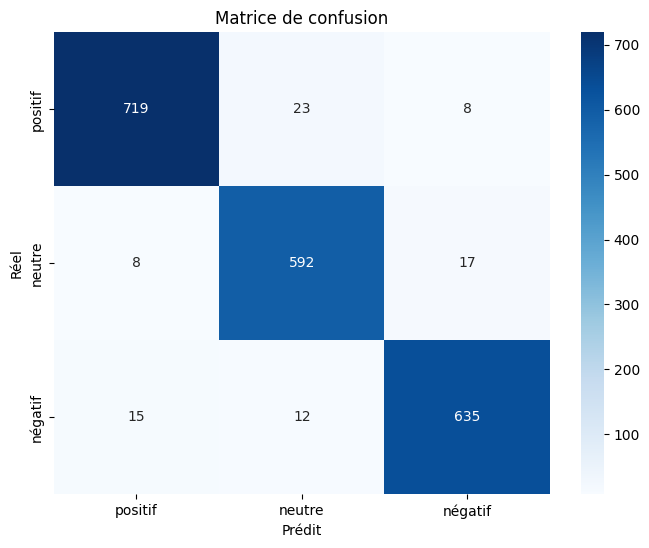

In [ ]:

# 11. ÉVALUATION
print("\n" + "=" * 50)
print("📊 ÉVALUATION")
print("=" * 50)

predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)

print(f"\n📈 Précision : {accuracy_score(y_test, preds):.4f}")
print("\n📋 Rapport :")
print(classification_report(y_test, preds, target_names=['positif', 'neutre', 'négatif']))

# 12. MATRICE DE CONFUSION
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['positif', 'neutre', 'négatif'],
            yticklabels=['positif', 'neutre', 'négatif'])
plt.title('Matrice de confusion')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

In [ ]:
# 13. SAUVEGARDE
model.save_pretrained('./sentiment_model')
tokenizer.save_pretrained('./sentiment_model')
print("✅ Modèle sauvegardé")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Modèle sauvegardé


In [ ]:
# 14. FONCTION DE PRÉDICTION
def predict_sentiment(text):
    # Nettoyer le texte
    clean = clean_text(text)

    # Tokenizer
    inputs = tokenizer(clean, return_tensors="pt", truncation=True, padding=True, max_length=256)

    # Déplacer sur le même périphérique que le modèle
    device = next(model.parameters()).device
    inputs = {key: val.to(device) for key, val in inputs.items()}

    # Prédiction
    with torch.no_grad():
        outputs = model(**inputs)

    # Récupérer la classe
    pred_id = torch.argmax(outputs.logits, dim=-1).item()
    sentiment = id_to_sentiment[pred_id]

    # Probabilités (les remettre sur CPU pour l'affichage)
    probs = torch.softmax(outputs.logits, dim=-1).squeeze().cpu().tolist()

    return sentiment, probs


# 15. TEST
print("\n" + "=" * 50)
print("🔮 TEST")
print("=" * 50)

test_comments = [
    "Ce produit est génial, je l'adore !",
    "Service client déplorable, très déçu.",
    "Produit correct, sans plus.",
    "Je recommande vivement, excellent service !",
    "Déçu par la qualité, trop cher pour ce que c'est.",
]

for comment in test_comments:
    sentiment, probs = predict_sentiment(comment)
    print(f"\n📝 Commentaire : {comment}")
    print(f"   Sentiment prédit : {sentiment.upper()}")
    print(f"   Probabilités : positif={probs[0]:.3f}, neutre={probs[1]:.3f}, négatif={probs[2]:.3f}")


🔮 TEST

📝 Commentaire : Ce produit est génial, je l'adore !
   Sentiment prédit : POSITIVE
   Probabilités : positif=0.998, neutre=0.001, négatif=0.001

📝 Commentaire : Service client déplorable, très déçu.
   Sentiment prédit : NEGATIVE
   Probabilités : positif=0.003, neutre=0.004, négatif=0.993

📝 Commentaire : Produit correct, sans plus.
   Sentiment prédit : NEUTRAL
   Probabilités : positif=0.001, neutre=0.997, négatif=0.002

📝 Commentaire : Je recommande vivement, excellent service !
   Sentiment prédit : POSITIVE
   Probabilités : positif=0.998, neutre=0.001, négatif=0.001

📝 Commentaire : Déçu par la qualité, trop cher pour ce que c'est.
   Sentiment prédit : NEGATIVE
   Probabilités : positif=0.001, neutre=0.011, négatif=0.988
